In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
data = pd.read_csv("suv_data.csv")

In [4]:
data

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510.0,Male,19.0,19000.0,0.0
1,15810944.0,Male,35.0,20000.0,0.0
2,15668575.0,Female,26.0,43000.0,0.0
3,15603246.0,Female,27.0,57000.0,0.0
4,15804002.0,Male,19.0,76000.0,0.0
...,...,...,...,...,...
395,15691863.0,Female,46.0,41000.0,1.0
396,15706071.0,Male,51.0,23000.0,1.0
397,15654296.0,Female,50.0,20000.0,1.0
398,15755018.0,Male,36.0,33000.0,0.0


In [5]:
data.head() ## first 5 rowws

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510.0,Male,19.0,19000.0,0.0
1,15810944.0,Male,35.0,20000.0,0.0
2,15668575.0,Female,26.0,43000.0,0.0
3,15603246.0,Female,27.0,57000.0,0.0
4,15804002.0,Male,19.0,76000.0,0.0


In [6]:
data.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='str')

In [8]:
data.value_counts()

User ID     Gender  Age   EstimatedSalary  Purchased
15624510.0  Male    19.0  19000.0          0.0          1
15810944.0  Male    35.0  20000.0          0.0          1
15668575.0  Female  26.0  43000.0          0.0          1
15603246.0  Female  27.0  57000.0          0.0          1
15804002.0  Male    19.0  76000.0          0.0          1
                                                       ..
15691863.0  Female  46.0  41000.0          1.0          1
15706071.0  Male    51.0  23000.0          1.0          1
15654296.0  Female  50.0  20000.0          1.0          1
15755018.0  Male    36.0  33000.0          0.0          1
15594041.0  Female  49.0  36000.0          1.0          1
Name: count, Length: 400, dtype: int64

In [9]:
data.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [18]:
for var in data.columns:  ### we looped through column names and printed the datatypes of the columns
    print(f"{var} -- {data[var].dtypes}")

User ID -- float64
Gender -- str
Age -- float64
EstimatedSalary -- float64
Purchased -- float64


In [22]:
for var in data.columns:   ### we looped through column names and printed the null values in all columns and there are no missing values
    print(f"{var} --> {data[var].isna().sum()}")

User ID --> 0
Gender --> 0
Age --> 0
EstimatedSalary --> 0
Purchased --> 0


In [25]:
data = data.drop("User ID", axis=1) ##we have dropped User_Id Column along with axis=1 as it was not required for estimation of logistic regression column

In [27]:
data

,Gender,Age,EstimatedSalary,Purchased
0,Male,19.0,19000.0,0.0
1,Male,35.0,20000.0,0.0
2,Female,26.0,43000.0,0.0
3,Female,27.0,57000.0,0.0
4,Male,19.0,76000.0,0.0
...,...,...,...,...
395,Female,46.0,41000.0,1.0
396,Male,51.0,23000.0,1.0
397,Female,50.0,20000.0,1.0
398,Male,36.0,33000.0,0.0


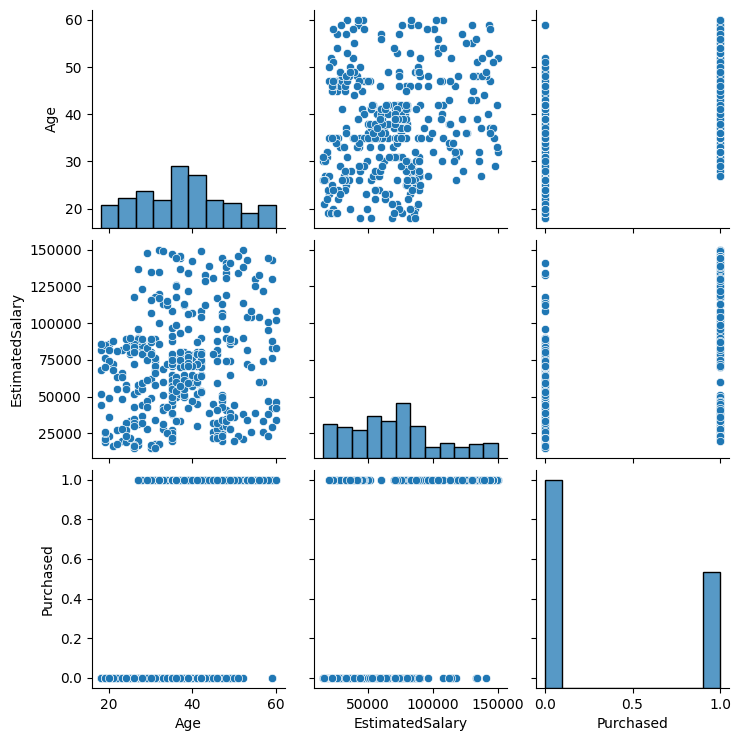

In [35]:
sns.pairplot(data);

### BOX - Plot

* Why did we choose Box Plot ->

 1. Shows median (center) → male vs female comparison easy.
 2. Shows spread (IQR) → salary variation
 3. Shows outliers → important for salary data

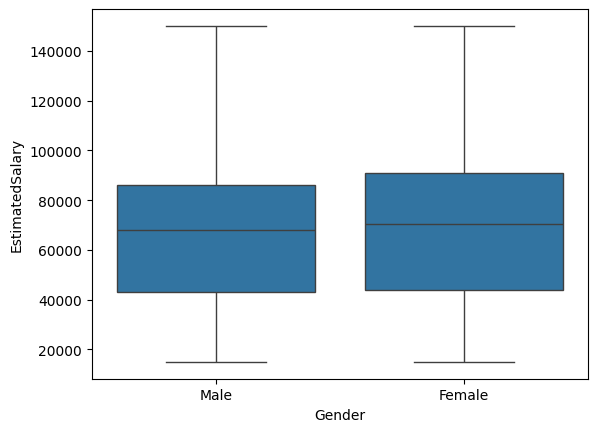

In [37]:
sns.boxplot(x="Gender", y="EstimatedSalary", data=data);

### Violin plot

1. Shows distribution shape (density)
Helps answer:
  * Are salaries concentrated?
  * Is one gender more spread out?
  * Any skewness?

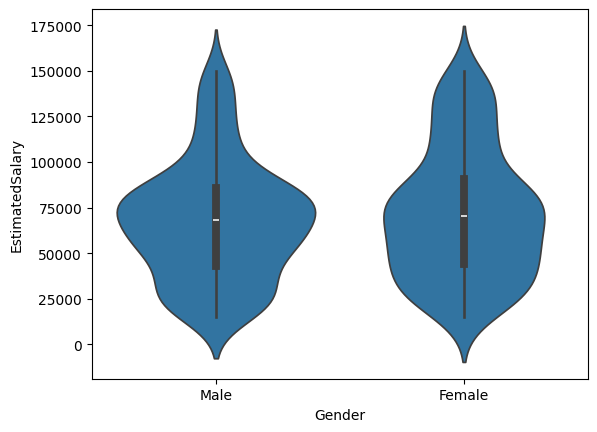

In [38]:
sns.violinplot(x="Gender", y="EstimatedSalary", data=data)
plt.show()

### Encoding Categorical Variables

In [39]:
data

,Gender,Age,EstimatedSalary,Purchased
0,Male,19.0,19000.0,0.0
1,Male,35.0,20000.0,0.0
2,Female,26.0,43000.0,0.0
3,Female,27.0,57000.0,0.0
4,Male,19.0,76000.0,0.0
...,...,...,...,...
395,Female,46.0,41000.0,1.0
396,Male,51.0,23000.0,1.0
397,Female,50.0,20000.0,1.0
398,Male,36.0,33000.0,0.0


### Which Encoding Method is preferred.?

* We will use One Hot Encoding as using Label Encoding and giving labels like 1 -> Male and 0 -> the problem with Label Encoding is that it might introduce artificial ordinal relationship like 1>0 but in reality male is not greater than female rather they are just nominal categories not order

In [62]:
data = pd.get_dummies(data, columns=["Gender"])

### Now let us fit our linear regression model


In [49]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 5.5 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.0 MB 5.0 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.0 MB 5.6 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.0 MB 5.9 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.0 MB 5.6 MB/s eta 0:00:01
   ---------------------------------- ----- 6.8/8.0 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.0 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 5.7 MB/s  0:00:01
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.5 MB 7.0 MB/s eta 0:00:06
   --- ------------------------------------ 2.9/36.5 MB 6.9 MB/s eta 0:00:05
   ---- ----------------------------------- 3.9/36.5 MB 6.5 MB/s eta 0:00:05
   ------ ---------------

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [68]:
X = data.drop("Purchased", axis=1)
y = data["Purchased"]

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)         

In [70]:
X_train.shape

(320, 4)

In [71]:
X_test.shape

(80, 4)

In [72]:
data["Gender_Male"] = data["Gender_Male"].astype(int)
data["Gender_Female"] = data["Gender_Female"].astype(int)

In [73]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [77]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [78]:
y_pred = model.predict(X_test)

In [79]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8875


In [80]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Confusion Matrix:
 [[50  2]
 [ 7 21]]


In [81]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.96      0.92        52
         1.0       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



In [82]:
# Train accuracy
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

# Test accuracy (you already have)
test_acc = accuracy_score(y_test, y_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.815625
Test Accuracy: 0.8875


In [83]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5)

print("CV Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

CV Scores: [0.796875 0.859375 0.828125 0.765625 0.8125  ]
Mean CV Score: 0.8125


### “The model is not overfitting since it performs better on unseen data than training data. This may indicate good generalization or slight underfitting.”

This situation can also mean:

🔸 Data Leakage (rare but dangerous)

In [84]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5)

print("CV Mean:", cv_scores.mean())

CV Mean: 0.8125


### 📊 Deep Analysis
✅ 1. Train ≈ CV
0.81 ≈ 0.8125

👉 Model's true performance ~0.81 

✔ Stable learning
✔ No overfitting
✔ Good generalization

### “The cross-validation score (~0.81) aligns with training accuracy, indicating stable generalization. The higher test accuracy (~0.88) is likely due to a favorable split, so CV is a more reliable estimate. The model shows no overfitting but may slightly underfit.”